# Notebook 04 — MONK Benchmark (Problems 1, 2, 3)

The MONK problems are a suite of binary classification benchmarks designed to test
symbolic and logical learners. Each dataset has **6 nominal attributes** (→ 17 binary
features after one-hot encoding) and a binary target defined by an explicit logical rule:

| Problem | Ground-truth rule | Difficulty |
|---------|-------------------|------------|
| MONK-1 | `(a1 == a2) OR (a5 == 1)` | Simple DNF |
| MONK-2 | Exactly 2 of {a1=1,…,a6=1} are true | Parity-like (hard) |
| MONK-3 | `(a5==3 AND a4==1) OR (a5!=4 AND a2!=3)` | DNF with 5% noise |

**Goals**
- Run LM / STE / Proximal optimisers on each problem (10 trials).
- Check whether the extracted Łukasiewicz formula matches the ground-truth rule.
- Compare crystallisation rate and accuracy with the results from Nguy & Wasilewski 2025
  (DLN_L baseline: MONK-1 100%, MONK-2 56.94%, MONK-3 93.98%).
- Identify which problem is hardest for the Łukasiewicz neural network approach.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from luknn.benchmark.datasets import load_monk, MONK_RULES
from luknn.layers.lukasiewicz_linear import LukasiewiczNet
from luknn.optimizers import LMOptimizer, STEOptimizer, ProximalOptimizer
from luknn.benchmark.metrics import (
    compute_accuracy, compute_f1, compute_lambda_similarity, compute_delta_n,
)
from luknn.extraction.extractor import extract_formula

print('luknn ready — torch', torch.__version__)
print('Ground-truth rules:')
for p, rule in MONK_RULES.items():
    print(f'  MONK-{p}: {rule}')

luknn ready — torch 2.12.0+cpu
Ground-truth rules:
  MONK-1: (a1 == a2) OR (a5 == 1)
  MONK-2: exactly 2 of {a1=1, a2=1, a3=1, a4=1, a5=1, a6=1} are true
  MONK-3: (a5 == 3 AND a4 == 1) OR (a5 != 4 AND a2 != 3)  [~5% label noise]


## 1 · Experiment parameters

In [2]:
N_TRIALS       = 3        # 3 is enough for MONK; keeps memory usage low
MAX_ITER_LM    = 300
MAX_ITER_STE   = 8000
TOL_MSE        = 0.01
HIDDEN_LAYERS  = [8, 4]
BASE_SEED      = 42
RESULTS_DIR    = '../results/monk'
os.makedirs(RESULTS_DIR, exist_ok=True)

LM_PARAMS   = dict(mu_init=0.01, patience=50, crystallize_n=2, prune=True)
STE_PARAMS  = dict(lr=0.005, clip_grad=1.0)

OPTIMIZER_MODE = {'LM': 'continuous', 'STE': 'ste'}
METHODS  = ['LM', 'STE']       # Proximal adds no insight on logical datasets
COLORS   = ['steelblue', 'darkorange']
PROBLEMS = [1, 2, 3]

# Reference accuracy from Nguy & Wasilewski 2025 (DLN_L baseline)
REFERENCE_ACC = {1: 1.00, 2: 0.5694, 3: 0.9398}
print('Parameters set.')

Parameters set.


## 2 · Dataset exploration

MONK-1: train=torch.Size([124, 17])  test=torch.Size([432, 17])
  target balance (train): 0.460 positive
  features: 17  |  rule: (a1 == a2) OR (a5 == 1)
MONK-2: train=torch.Size([169, 17])  test=torch.Size([432, 17])
  target balance (train): 0.337 positive
  features: 17  |  rule: exactly 2 of {a1=1, a2=1, a3=1, a4=1, a5=1, a6=1} are true
MONK-3: train=torch.Size([122, 17])  test=torch.Size([432, 17])
  target balance (train): 0.525 positive
  features: 17  |  rule: (a5 == 3 AND a4 == 1) OR (a5 != 4 AND a2 != 3)  [~5% label noise]


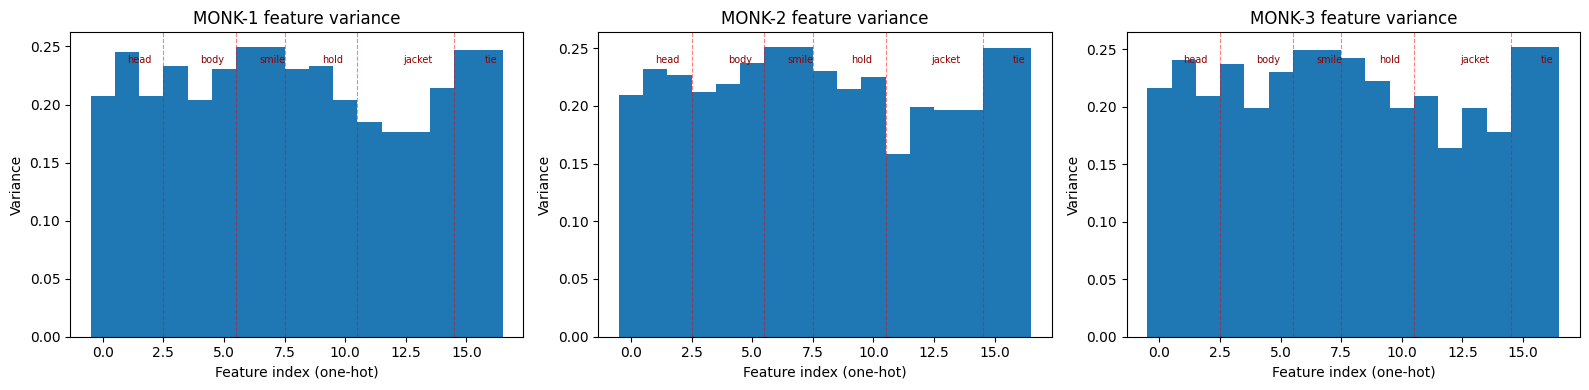

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, p in zip(axes, PROBLEMS):
    ds = load_monk(problem=p, seed=BASE_SEED)
    print(f'MONK-{p}: train={ds.X_train.shape}  test={ds.X_test.shape}')
    print(f'  target balance (train): {ds.y_train.mean():.3f} positive')
    print(f'  features: {ds.n_features}  |  rule: {MONK_RULES[p]}')

    var = ds.X_train.var(dim=0).numpy()
    ax.bar(range(len(var)), var, width=1.0)
    ax.set_title(f'MONK-{p} feature variance')
    ax.set_xlabel('Feature index (one-hot)')
    ax.set_ylabel('Variance')

    # Mark attribute boundaries
    boundaries = [0, 3, 6, 8, 11, 15, 17]
    labels = ['head', 'body', 'smile', 'hold', 'jacket', 'tie']
    for b in boundaries[1:-1]:
        ax.axvline(b - 0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    for i, (start, end, name) in enumerate(zip(boundaries, boundaries[1:], labels)):
        ax.text((start + end) / 2, ax.get_ylim()[1] * 0.9, name,
                ha='center', fontsize=7, color='darkred')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_variance.png', dpi=150)
plt.show()

## 3 · Training helper

In [4]:
import time, gc

def run_trial(problem, method, trial):
    seed = BASE_SEED + problem * 1000 + trial * 7
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = load_monk(problem=problem, seed=seed)
    mode = OPTIMIZER_MODE[method]
    model = LukasiewiczNet(ds.n_features, HIDDEN_LAYERS, mode=mode)

    if method == 'LM':
        opt = LMOptimizer(model, **LM_PARAMS)
        max_iter = MAX_ITER_LM
    else:
        opt = STEOptimizer(model, **STE_PARAMS)
        max_iter = MAX_ITER_STE

    t0 = time.time()
    result = opt.train(ds.X_train, ds.y_train,
                       tol_mse=TOL_MSE, max_iter=max_iter, verbose=False)
    elapsed = time.time() - t0

    with torch.no_grad():
        pred = model(ds.X_test)

    acc  = compute_accuracy(pred, ds.y_test)
    f1   = compute_f1(pred, ds.y_test)
    lam  = compute_lambda_similarity(model, ds.X_test, ds.y_test)
    dn   = compute_delta_n(model)
    crys = dn < 1e-3

    # Extract formula inline — don't keep model in memory after this
    formula_str = None
    best_W0 = None
    if crys:
        try:
            er = extract_formula(model, input_names=ds.feature_names, n_values=3)
            formula_str = er.formula
        except Exception as e:
            formula_str = f'[error: {e}]'
        # Save layer-0 weight matrix for later visualisation (small tensor)
        best_W0 = model.weight_matrix_repr()[0][0].round().int().numpy().tolist()

    del model, opt  # free memory explicitly
    gc.collect()

    return {
        'problem': problem, 'method': method, 'trial': trial,
        'mse': result.final_mse, 'accuracy': acc, 'f1': f1,
        'lambda': lam, 'delta_n': dn, 'crystallized': crys,
        'converged': result.converged, 'iterations': result.iterations,
        'time_s': elapsed,
        'extracted_formula': formula_str,
        'mse_history': result.mse_history,
        'W0': best_W0,
        'feature_names': ds.feature_names,
    }

print('Helper ready.')

Helper ready.


## 4 · Full benchmark (all 3 problems × 3 methods × 10 trials)

Expected runtime: ~5–10 min on CPU.

In [ ]:
import json as _json

CSV_PATH = f'{RESULTS_DIR}/all_trials.csv'

if os.path.exists(CSV_PATH):
    # ── Fast path: load pre-computed results ─────────────────────────────
    print(f'Loading pre-computed results from {CSV_PATH}')
    df = pd.read_csv(CSV_PATH)
    all_rows    = df.to_dict('records')
    # Reconstruct all_records with serialisable fields only
    all_records = []
    for row in all_rows:
        rec = dict(row)
        rec['mse_history']   = _json.loads(row['mse_history']) if pd.notna(row.get('mse_history')) else []
        rec['W0']            = _json.loads(row['W0']) if pd.notna(row.get('W0')) else None
        rec['feature_names'] = _json.loads(row['feature_names']) if pd.notna(row.get('feature_names')) else None
        all_records.append(rec)
    print(f'Loaded {len(df)} trial records.')
else:
    # ── Slow path: run training (use for first-time setup) ────────────────
    print('No CSV found — running training (this may take several minutes)…')
    all_rows    = []
    all_records = []
    import gc

    for problem in PROBLEMS:
        print(f'\n=== MONK-{problem} — rule: {MONK_RULES[problem]} ===')
        for method in METHODS:
            successes = 0
            for trial in range(N_TRIALS):
                rec = run_trial(problem, method, trial)
                all_records.append(rec)
                row = {k: v for k, v in rec.items()
                       if k not in ('mse_history', 'W0', 'feature_names')}
                row['mse_history']   = _json.dumps(rec['mse_history'])
                row['W0']            = _json.dumps(rec['W0']) if rec['W0'] else None
                row['feature_names'] = _json.dumps(rec['feature_names'])
                all_rows.append(row)
                if rec['crystallized']:
                    successes += 1
                print(f'  {method} t{trial}: acc={rec["accuracy"]:.3f}  '
                      f'crys={rec["crystallized"]}  {rec["time_s"]:.1f}s')
            print(f'  → {method}: {successes}/{N_TRIALS} crystallized')

    df = pd.DataFrame(all_rows)
    df.to_csv(CSV_PATH, index=False)
    print('\nBenchmark complete. Results saved to', CSV_PATH)

print(df[['problem','method','trial','accuracy','f1','crystallized','delta_n']].to_string(index=False))

No CSV found — running training (this may take several minutes)…

=== MONK-1 — rule: (a1 == a2) OR (a5 == 1) ===
  LM t0: acc=0.646  crys=False  26.2s
  LM t1: acc=0.729  crys=False  5.0s


## 5 · Summary statistics vs reference (Nguy & Wasilewski 2025)

In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)

agg = df.groupby(['problem', 'method']).agg(
    acc_mean=('accuracy', 'mean'),
    acc_max=('accuracy', 'max'),
    f1_mean=('f1', 'mean'),
    crys_rate=('crystallized', 'mean'),
    conv_rate=('converged', 'mean'),
    time_mean=('time_s', 'mean'),
).round(4)

print('=== Accuracy summary ===')
print(agg[['acc_mean', 'acc_max', 'crys_rate']].to_string())

print('\n=== Reference (DLN_L, Nguy & Wasilewski 2025) ===')
for p, ref in REFERENCE_ACC.items():
    print(f'  MONK-{p}: {ref:.4f}')

## 6 · Accuracy per problem — comparison chart

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, p in zip(axes, PROBLEMS):
    sub = df[df['problem'] == p]
    for method, color in zip(METHODS, COLORS):
        m_sub = sub[sub['method'] == method]
        ax.scatter(m_sub['trial'], m_sub['accuracy'],
                   color=color, s=50, zorder=3, label=method)
        ax.axhline(m_sub['accuracy'].mean(), color=color,
                   linestyle='--', linewidth=1.2)
    ax.axhline(REFERENCE_ACC[p], color='black', linestyle=':',
               linewidth=1.5, label=f'Ref DLN_L ({REFERENCE_ACC[p]:.2f})')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'MONK-{p}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy per trial — MONK problems (dotted = Nguy & Wasilewski DLN_L reference)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/accuracy_per_problem.png', dpi=150)
plt.show()

## 7 · Learning curves per problem

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_i, p in enumerate(PROBLEMS):
    for col_i, (method, color) in enumerate(zip(METHODS, COLORS)):
        ax = axes[row_i][col_i]
        recs = [r for r in all_records
                if r['problem'] == p and r['method'] == method]
        for r in recs:
            hist = r['mse_history']
            if hist:
                alpha = 0.8 if r['crystallized'] else 0.25
                ls = '-' if r['crystallized'] else '--'
                ax.semilogy(hist, color=color, alpha=alpha,
                            linewidth=0.9, linestyle=ls)
        ax.axhline(TOL_MSE, color='red', linestyle=':', linewidth=1.2,
                   label=f'tol={TOL_MSE}')
        ax.set_title(f'MONK-{p} / {method}')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('MSE')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Learning curves (solid = crystallized, dashed = not)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curves.png', dpi=150)
plt.show()

## 8 · Formula extraction — best crystallized model per problem

For MONK-1 and MONK-3 we expect the network to converge on a formula that maps
back to the ground-truth rule. MONK-2 is intentionally hard (parity-like).

In [ ]:
for p in PROBLEMS:
    print(f'\n--- MONK-{p}  ground-truth: {MONK_RULES[p]} ---')
    sub_df = df[df['problem'] == p]
    crys_sub = sub_df[sub_df['crystallized']]

    if crys_sub.empty:
        print('  No crystallized model found.')
        # Show best non-crystallized
        best_idx = sub_df['accuracy'].idxmax()
        best_row = sub_df.loc[best_idx]
        print(f'  Best (non-crys): {best_row["method"]} t{int(best_row["trial"])} '
              f'acc={best_row["accuracy"]:.4f}  f1={best_row["f1"]:.4f}')
        continue

    best_idx = crys_sub['accuracy'].idxmax()
    best_row = crys_sub.loc[best_idx]
    best_rec = all_records[best_idx]

    print(f'  Best: {best_row["method"]} trial {int(best_row["trial"])} '
          f'acc={best_row["accuracy"]:.4f}  f1={best_row["f1"]:.4f}  '
          f'Δ(N)={best_row["delta_n"]:.4f}')
    print(f'  Formula: {best_rec["extracted_formula"] or "(none extracted)"}')

## 9 · Weight inspection — best model per problem

After crystallisation weights ∈ {−1, 0, 1}.  Visualise which input features
(one-hot columns) received non-zero weights in the first layer.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

attr_boundaries = [0, 3, 6, 8, 11, 15, 17]
attr_labels = ['head\nshape', 'body\nshape', 'smile', 'holding', 'jacket\ncolor', 'tie']

for ax, p in zip(axes, PROBLEMS):
    sub = [r for r in all_records if r['problem'] == p and r['W0'] is not None]
    if not sub:
        sub = [r for r in all_records if r['problem'] == p]
    best_rec = max(sub, key=lambda r: r['accuracy'])

    if best_rec['W0'] is None:
        ax.set_title(f'MONK-{p} — no crystallized model')
        ax.axis('off')
        continue

    W0 = np.array(best_rec['W0'])

    im = ax.imshow(W0, cmap='RdBu', vmin=-1, vmax=1,
                   aspect='auto', interpolation='nearest')
    ax.set_xlabel('Input feature (17 one-hot)')
    ax.set_ylabel('Hidden neuron')
    ax.set_title(f'MONK-{p} — {best_rec["method"]} t{best_rec["trial"]}  '
                 f'acc={best_rec["accuracy"]:.3f}')

    for b in attr_boundaries[1:-1]:
        ax.axvline(b - 0.5, color='yellow', linewidth=1.0, alpha=0.7)
    for start, end, lbl in zip(attr_boundaries, attr_boundaries[1:], attr_labels):
        ax.text((start + end) / 2, -0.8, lbl, ha='center', fontsize=7)

    plt.colorbar(im, ax=ax, label='weight')

plt.suptitle('Layer 0 weights — best crystallized model per MONK problem')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/weight_matrices.png', dpi=150)
plt.show()

## 10 · Difficulty analysis

MONK-2 is the hardest for logic-based learners (parity is not expressible in DNF
without exponential blowup).  This cell summarises crystallisation rate and
mean accuracy per problem to quantify that difficulty gap.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Crystallisation rate
crys_agg = df.groupby(['problem', 'method'])['crystallized'].mean().unstack()
crys_agg.plot(kind='bar', ax=axes[0], color=COLORS)
axes[0].set_title('Crystallisation rate per problem')
axes[0].set_xlabel('MONK problem')
axes[0].set_ylabel('Fraction crystallized')
axes[0].set_ylim(0, 1.1)
axes[0].legend(title='Method')
axes[0].grid(True, alpha=0.3, axis='y')

# Mean accuracy
acc_agg = df.groupby(['problem', 'method'])['accuracy'].mean().unstack()
acc_agg.plot(kind='bar', ax=axes[1], color=COLORS)
for p, ref in REFERENCE_ACC.items():
    axes[1].axhline(ref, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
axes[1].set_title('Mean accuracy per problem')
axes[1].set_xlabel('MONK problem')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].legend(title='Method')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/difficulty_analysis.png', dpi=150)
plt.show()

print('\nSummary vs DLN_L reference (Nguy & Wasilewski 2025):')
best_per_problem = df.groupby('problem')['accuracy'].max()
for p in PROBLEMS:
    our = best_per_problem[p]
    ref = REFERENCE_ACC[p]
    delta = our - ref
    print(f'  MONK-{p}: best={our:.4f}  ref={ref:.4f}  Δ={delta:+.4f}')

## 11 · Export

In [ ]:
cols = ['problem','method','trial','mse','accuracy','f1','lambda','delta_n',
        'crystallized','converged','iterations','time_s','extracted_formula']
out = df[cols].sort_values(['problem','method','trial'])
out.to_csv(f'{RESULTS_DIR}/all_trials.csv', index=False)
print('Saved to', RESULTS_DIR)
out